# Sequential Distribution Updating

ProbPipe provides a general framework for algorithms that **iteratively transform a distribution over a sequence of steps**. The core abstraction is a *fold over distributions*: starting from an initial distribution, a step function is applied repeatedly with successive inputs, producing a trajectory.

Key components:

- **`iterate`** — fold a step function over inputs, collecting a `TransitionTrace`
- **`StepResult`** — pairs a distribution with auxiliary info (diagnostics, ESS, etc.)
- **`TransitionTrace`** — the full trajectory: `.distributions`, `.final`, `.infos`
- **`ConditioningStep`** — a reusable step function for Bayesian conditioning
- **`with_approximation`** — combinator: convert the output distribution after each step
- **`with_resampling`** — combinator: resample particles when weights degenerate
- **`IncrementalConditioner`** — convenience Module wrapping `ConditioningStep` + `iterate`

This notebook demonstrates each of these on concrete examples.

In [1]:
import warnings
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype.*float64.*")

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (
    MultivariateNormal, EmpiricalDistribution,
    SimpleModel, from_distribution, mean, provenance_ancestors, Provenance,
    sample as pp_sample,
    StepResult, TransitionTrace, iterate,
    with_approximation, with_resampling,
    ConditioningStep, IncrementalConditioner,
)
from probpipe.modeling import Likelihood

rng = np.random.default_rng(42)

## The Core Pattern: `iterate`

At the lowest level, `iterate` folds a **step function** over a sequence of inputs. A step function is any callable with signature `(Distribution, input) -> Distribution` (or `-> StepResult` to attach auxiliary info). No base class needed.

Let's start with a trivial example: shifting an empirical distribution by successive offsets.

In [2]:
# A step function is just a callable: (Distribution, input) -> Distribution
def shift_step(dist, offset):
    """Shift all samples by an offset."""
    return EmpiricalDistribution(dist.samples + offset)

initial = EmpiricalDistribution(jnp.zeros((200, 2)), name="start")
offsets = [1.0, 0.5, -0.3]

trace = iterate(shift_step, initial, offsets)

print(f"Steps taken:    {len(trace)}")
print(f"Trajectory len: {len(trace.distributions)} (initial + {len(trace)} steps)")
print(f"Final mean:     {mean(trace.final)}")
print(f"Expected:       {sum(offsets):.1f}")

Steps taken:    3
Trajectory len: 4 (initial + 3 steps)
Final mean:     [1.2000003 1.2000003]
Expected:       1.2


## StepResult and Auxiliary Info

When a step function returns a `StepResult` instead of a bare `Distribution`, it can attach an `info` dict with auxiliary data — diagnostics, log-normalizing constants, ESS, or anything else. The `TransitionTrace` collects these across all steps.

In [3]:
def shift_with_info(dist, offset):
    """Shift samples and record the offset applied."""
    new_samples = dist.samples + offset
    new_dist = EmpiricalDistribution(new_samples)
    return StepResult(
        distribution=new_dist,
        info={"offset": float(offset), "sample_mean": float(jnp.mean(new_samples))},
    )

trace = iterate(shift_with_info, initial, [1.0, 2.0, 3.0])

print("Per-step info:")
for i, info in enumerate(trace.infos):
    print(f"  Step {i}: offset={info['offset']:.1f}, sample_mean={info['sample_mean']:.1f}")

# Extract a single key across all steps
print(f"\nAll offsets: {trace.info_values('offset')}")

Per-step info:
  Step 0: offset=1.0, sample_mean=1.0
  Step 1: offset=2.0, sample_mean=3.0
  Step 2: offset=3.0, sample_mean=6.0

All offsets: [1.0, 2.0, 3.0]


## Provenance Tracking

Each step's output distribution automatically receives a `Provenance` link to its parent, forming a chain that `provenance_ancestors` can traverse. If the step function sets its own provenance, `iterate` respects it.

In [4]:
trace = iterate(shift_step, initial, [1.0, 2.0, 3.0])

final = trace.final
print(f"Final source:  {final.source}")
print(f"Parent chain:  {[type(a).__name__ + (f'({a.name})' if a.name else '') for a in provenance_ancestors(final)]}")

# Each step links to the previous
for i in range(len(trace)):
    src = trace[i].distribution.source
    parent_name = src.parents[0].name or type(src.parents[0]).__name__
    print(f"  Step {i}: operation='{src.operation}', parent='{parent_name}'")

Final source:  Provenance('iterate', parents=[ArrayEmpiricalDistribution])
Parent chain:  ['ArrayEmpiricalDistribution', 'ArrayEmpiricalDistribution', 'ArrayEmpiricalDistribution(start)']
  Step 0: operation='iterate', parent='start'
  Step 1: operation='iterate', parent='ArrayEmpiricalDistribution'
  Step 2: operation='iterate', parent='ArrayEmpiricalDistribution'


## Callbacks and Early Stopping

Pass a `callback` to `iterate` for logging, progress tracking, or early stopping. The callback receives `(step_index, step_result)` after each step. Return `False` to stop early.

In [5]:
def stop_when_large(i, result):
    m = float(jnp.mean(result.distribution.samples))
    print(f"  Step {i}: mean = {m:.2f}")
    if m > 3.0:
        print(f"  -> Stopping early (mean > 3.0)")
        return False

trace = iterate(shift_step, initial, [1.0, 1.5, 2.0, 2.5], callback=stop_when_large)
print(f"Steps completed: {len(trace)} (out of 4 inputs)")

  Step 0: mean = 1.00
  Step 1: mean = 2.50
  Step 2: mean = 4.50
  -> Stopping early (mean > 3.0)
Steps completed: 3 (out of 4 inputs)


## Bayesian Sequential Updating with `ConditioningStep`

`ConditioningStep` is a `WorkflowFunction` that builds a `SimpleModel` from the current distribution and a likelihood, then conditions on observed data. It's the standard step function for sequential Bayesian updating.

We'll use **Gaussian mean estimation** as a running example: observations $y_i \sim \mathcal{N}(\boldsymbol{\mu}, I)$ where $\boldsymbol{\mu}$ is a 2-D mean vector to infer. We use a lightweight mock conditioning function to keep the notebook fast — in practice you'd use `condition_on` which runs NUTS/HMC.

In [6]:
# --- Data generation ---
true_mu = jnp.array([2.0, -1.0])
n_total = 200
y_all = jnp.array(rng.multivariate_normal(np.array(true_mu), np.eye(2), size=n_total))

# --- Likelihood ---
class GaussianLikelihood:
    """Isotropic Gaussian likelihood: y_i ~ N(mu, I)."""
    def log_likelihood(self, params, data):
        residuals = jnp.asarray(data) - params[None, :]
        return -0.5 * jnp.sum(residuals ** 2)

likelihood = GaussianLikelihood()
print(f"True mu: {true_mu}")
print(f"Satisfies Likelihood protocol: {isinstance(likelihood, Likelihood)}")

True mu: [ 2. -1.]
Satisfies Likelihood protocol: True


In [7]:
# Lightweight conditioning function that simulates MCMC:
# draws samples around the data mean, shrunk toward the prior.
def mock_condition(model, data, **kwargs):
    """Approximate posterior via simple Bayesian update (known variance)."""
    prior = model["parameters"]
    prior_mean = mean(prior)
    data = jnp.asarray(data)
    n = data.shape[0]
    # Conjugate Gaussian update (known unit variance)
    prior_prec = jnp.linalg.inv(jnp.array([[10., 0.], [0., 10.]]))
    data_prec = n * jnp.eye(2)
    post_prec = prior_prec + data_prec
    post_cov = jnp.linalg.inv(post_prec)
    post_mean = post_cov @ (prior_prec @ prior_mean + data_prec @ jnp.mean(data, axis=0))
    # Return samples from the exact posterior
    key = jax.random.PRNGKey(hash(str(data[:3])) % (2**31))
    samples = jax.random.multivariate_normal(key, post_mean, post_cov, shape=(500,))
    return EmpiricalDistribution(samples, name="posterior")

# --- ConditioningStep: directly callable with iterate ---
step = ConditioningStep(likelihood, condition_fn=mock_condition)
prior = MultivariateNormal(loc=jnp.zeros(2), cov=10.0 * jnp.eye(2), name="prior")

# Split data into 4 batches of 50
batches = [y_all[i:i+50] for i in range(0, 200, 50)]

# Approximate each posterior as MVN so it can serve as the next prior
approx_step = with_approximation(step, MultivariateNormal, name="posterior")

trace = iterate(approx_step, prior, batches)

print(f"Batches processed: {len(trace)}")
for i, dist in enumerate(trace.distributions):
    print(f"  Distribution {i}: {type(dist).__name__}, mean = {mean(dist)}")
print(f"\nTrue mu: {true_mu}")

Batches processed: 4
  Distribution 0: MultivariateNormal, mean = [0. 0.]
  Distribution 1: MultivariateNormal, mean = [ 1.9647932 -1.0597328]
  Distribution 2: MultivariateNormal, mean = [ 2.0161688 -1.034679 ]
  Distribution 3: MultivariateNormal, mean = [ 1.9732609 -1.1020223]
  Distribution 4: MultivariateNormal, mean = [ 2.1454716 -0.9385806]

True mu: [ 2. -1.]


W0406 14:24:08.115671 3232218 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


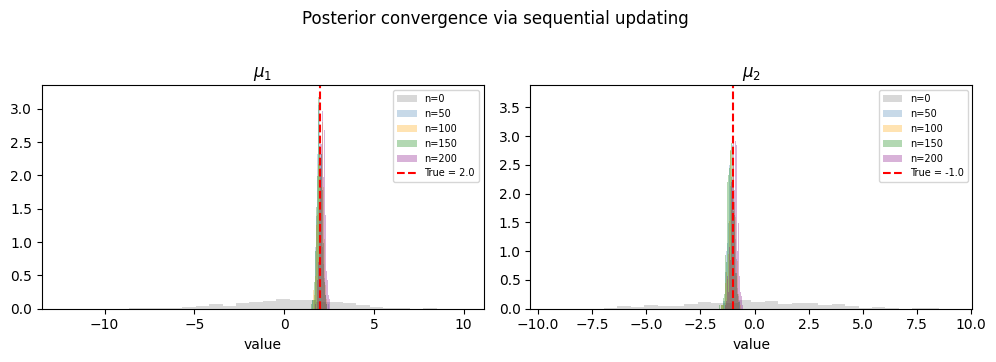

In [8]:
# Visualize posterior convergence across batches
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

colors = ['gray', 'steelblue', 'orange', 'green', 'purple']
for i, dist in enumerate(trace.distributions):
    n_seen = i * 50
    label = f'n={n_seen}' if i == 0 else f'n={n_seen}'
    samples = np.array(pp_sample(dist, key=jax.random.PRNGKey(i), sample_shape=(500,)))
    ax1.hist(samples[:, 0], bins=30, density=True,
             alpha=0.3, color=colors[i], label=label)
    ax2.hist(samples[:, 1], bins=30, density=True,
             alpha=0.3, color=colors[i], label=label)

for ax, comp, true_val in [(ax1, 0, true_mu[0]), (ax2, 1, true_mu[1])]:
    ax.axvline(float(true_val), color='red', linestyle='--', label=f'True = {true_val}')
    ax.set_xlabel('value')
    ax.legend(fontsize=7)

ax1.set_title(r'$\mu_1$')
ax2.set_title(r'$\mu_2$')
plt.suptitle('Posterior convergence via sequential updating', y=1.02)
plt.tight_layout()
plt.show()

## `IncrementalConditioner` — Convenience Module

`IncrementalConditioner` wraps `ConditioningStep` + `iterate` into a single Module for the common case. It returns a `TransitionTrace` directly.

In [9]:
# Wrap the condition function so it also approximates as Gaussian
def approx_condition(model, data):
    post = mock_condition(model, data)
    return from_distribution(post, MultivariateNormal, name="posterior")

conditioner = IncrementalConditioner(
    prior=prior,
    likelihood=likelihood,
    condition_fn=approx_condition,
)

trace = conditioner.update(data_batches=batches)

print(f"Steps: {len(trace)}")
print(f"Final posterior mean: {mean(trace.final)}")
print(f"True mu:             {true_mu}")

Steps: 4
Final posterior mean: [ 2.1454716 -0.9385806]
True mu:             [ 2. -1.]


## Combinator: `with_resampling`

When working with weighted particles (e.g., importance sampling or tempering), weights can degenerate — a few particles dominate while the rest carry negligible weight. `with_resampling` monitors the **effective sample size** (ESS) after each step and resamples to uniform weights when `ESS / N` drops below a threshold.

Here we simulate a tempering-like scenario where particles are progressively reweighted toward a target.

In [10]:
def tempering_step(dist, beta_increment):
    """Reweight particles by a tempered quadratic likelihood."""
    samples = dist.samples
    target = jnp.array([2.0, 2.0])
    log_lik = -0.5 * jnp.sum((samples - target) ** 2, axis=1)

    # Combine existing log-weights with tempered likelihood
    old_log_w = dist._w.log_normalized
    new_log_w = old_log_w + beta_increment * log_lik
    return EmpiricalDistribution(samples, log_weights=new_log_w)

# Start with uniform-weighted samples from a wide prior
key = jax.random.PRNGKey(0)
prior_samples = jax.random.normal(key, shape=(500, 2)) * 3.0
particles = EmpiricalDistribution(prior_samples, name="prior_particles")

# Temper in 5 increments (beta goes 0 -> 1)
betas = [0.2, 0.2, 0.2, 0.2, 0.2]

# WITHOUT resampling
trace_no_resample = iterate(tempering_step, particles, betas)

# WITH resampling when ESS/N < 0.5
trace_resample = iterate(
    with_resampling(tempering_step, ess_threshold=0.5),
    particles, betas,
)

# Compare ESS trajectories
ess_no = [float(d._w.effective_sample_size) for d in trace_no_resample.distributions[1:]]
ess_yes = trace_resample.info_values('ess')
resampled = trace_resample.info_values('resampled')

print("Without resampling:")
for i, e in enumerate(ess_no):
    print(f"  Step {i}: ESS = {e:.1f} ({e/500*100:.0f}%)")

print("\nWith resampling (threshold=50%):")
for i, (e, r) in enumerate(zip(ess_yes, resampled)):
    print(f"  Step {i}: ESS = {e:.1f} ({e/500*100:.0f}%) {'[resampled]' if r else ''}")

Without resampling:
  Step 0: ESS = 245.5 (49%)
  Step 1: ESS = 160.4 (32%)
  Step 2: ESS = 118.8 (24%)
  Step 3: ESS = 93.6 (19%)
  Step 4: ESS = 76.5 (15%)

With resampling (threshold=50%):
  Step 0: ESS = 245.5 (49%) [resampled]
  Step 1: ESS = 414.3 (83%) 
  Step 2: ESS = 326.6 (65%) 
  Step 3: ESS = 263.5 (53%) 
  Step 4: ESS = 217.8 (44%) [resampled]


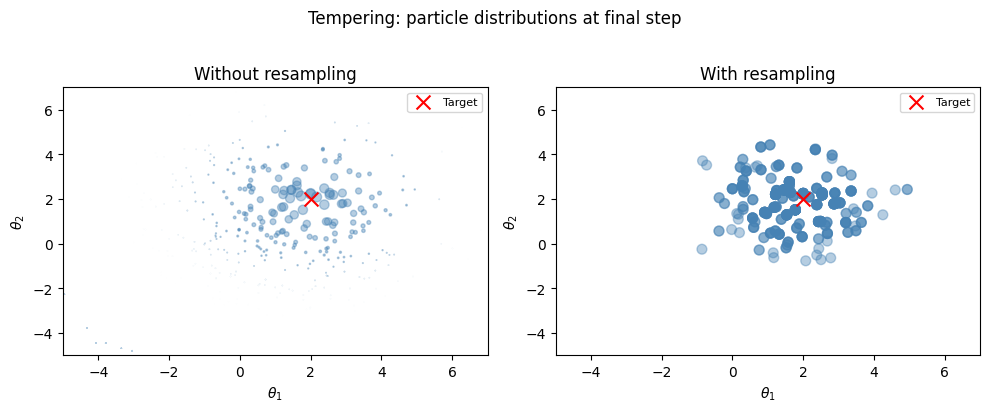

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, tr, title in [(axes[0], trace_no_resample, 'Without resampling'),
                       (axes[1], trace_resample, 'With resampling')]:
    final = tr.final
    s = np.array(final.samples)
    w = np.array(final._w.normalized)
    sizes = w / w.max() * 50
    ax.scatter(s[:, 0], s[:, 1], s=sizes, alpha=0.4, c='steelblue')
    ax.scatter([2.0], [2.0], c='red', marker='x', s=100, zorder=5, label='Target')
    ax.set_xlim(-5, 7)
    ax.set_ylim(-5, 7)
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Tempering: particle distributions at final step', y=1.02)
plt.tight_layout()
plt.show()

## Nested Iteration

Step functions can call `iterate` internally — enabling algorithms like tempering-within-conditioning, where each outer step runs an inner loop. The framework composes naturally because `iterate` is just a function.

In [12]:
def inner_step(dist, value):
    """Simple inner step: shift samples."""
    return EmpiricalDistribution(dist.samples + value)

def outer_step(dist, batch):
    """Each outer step runs an inner iterate loop."""
    inner_trace = iterate(inner_step, dist, batch)
    return StepResult(
        distribution=inner_trace.final,
        info={"inner_steps": len(inner_trace), "inner_total_shift": sum(batch)},
    )

start = EmpiricalDistribution(jnp.zeros((100, 2)))
outer_inputs = [[0.1, 0.2, 0.3], [0.4, 0.5]]

trace = iterate(outer_step, start, outer_inputs)

print(f"Outer steps: {len(trace)}")
for i, result in enumerate(trace.results):
    info = result.info
    m = float(jnp.mean(result.distribution.samples))
    print(f"  Step {i}: {info['inner_steps']} inner steps, shift={info['inner_total_shift']:.1f}, mean={m:.2f}")
print(f"Total shift: {float(jnp.mean(trace.final.samples)):.2f} (expected {sum(sum(b) for b in outer_inputs):.2f})")

Outer steps: 2
  Step 0: 3 inner steps, shift=0.6, mean=0.60
  Step 1: 2 inner steps, shift=0.9, mean=1.50
Total shift: 1.50 (expected 1.50)


## Summary

| Component | Role | When to use |
|-----------|------|-------------|
| `iterate` | Fold a step function over inputs | Always — the core iteration utility |
| `StepResult` | Pair a distribution with auxiliary info | When your step produces diagnostics, ESS, etc. |
| `TransitionTrace` | Access the full trajectory | Inspecting convergence, plotting, provenance |
| `ConditioningStep` | Build model + condition in one step | Bayesian sequential updating |
| `with_approximation` | Convert output type after each step | MCMC posterior to parametric for next prior |
| `with_resampling` | Resample when ESS degenerates | Tempering, SMC, importance sampling |
| `IncrementalConditioner` | Convenience wrapper for sequential conditioning | Simple cases with a fixed likelihood |

Key takeaways:

- **A step function is any callable** `(Distribution, input) -> Distribution | StepResult` — no base class or decorator needed for simple cases.
- **`ConditioningStep`** is a `WorkflowFunction` subclass for step functions that need construction-time configuration (likelihood, condition function, inference kwargs).
- **Combinators compose**: `with_approximation(with_resampling(step, ...), ...)` wraps a step function with multiple post-processing behaviors.
- **`iterate` is a `WorkflowFunction`** — it participates in Prefect orchestration and broadcasting like all other ProbPipe operations.
- **Provenance is automatic**: each step's output links to its parent, enabling `provenance_ancestors` to trace the full history.